In [1]:
import json
import sys
sys.path.append('..')
from src.data_loader import load_pubmedqa

samples = load_pubmedqa('../data/pubmedqa_train.json')
print(f"Total samples: {len(samples)}")
print(f"\nSample keys: {list(samples[0].keys())}")
print(f"\nFirst question: {samples[0]['question']}")
print(f"Final decision: {samples[0]['final_decision']}")

Total samples: 1000

Sample keys: ['pubid', 'question', 'chunks', 'long_answer', 'final_decision']

First question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Final decision: yes


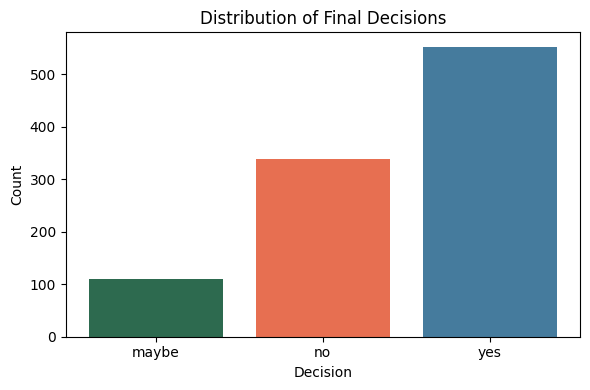

{'maybe': 110, 'no': 338, 'yes': 552}


In [2]:
import matplotlib.pyplot as plt

# 1. Distribution of final decisions (yes/no/maybe)
decisions = [s['final_decision'] for s in samples]
decision_counts = {d: decisions.count(d) for d in set(decisions)}

plt.figure(figsize=(6, 4))
plt.bar(decision_counts.keys(), decision_counts.values(), color=['#2d6a4f', '#e76f51', '#457b9d'])
plt.title('Distribution of Final Decisions')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(decision_counts)

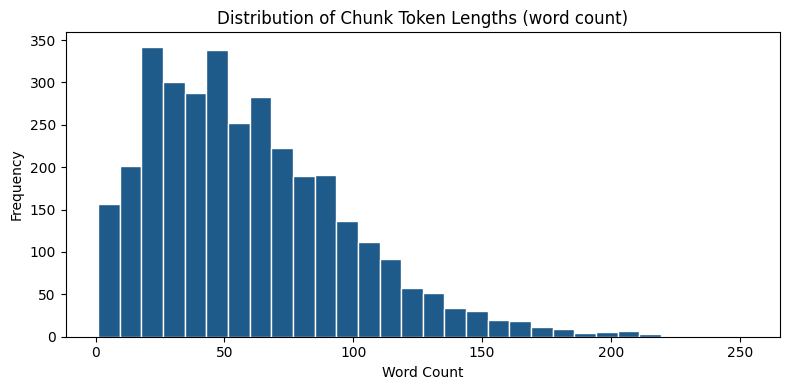

Min: 1
Max: 253
Average: 60


In [3]:
# 2. Token length distribution of chunks
chunk_lengths = []
for s in samples:
    for chunk in s['chunks']:
        chunk_lengths.append(len(chunk['text'].split()))

plt.figure(figsize=(8, 4))
plt.hist(chunk_lengths, bins=30, color='#1e5a8a', edgecolor='white')
plt.title('Distribution of Chunk Token Lengths (word count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Min: {min(chunk_lengths)}")
print(f"Max: {max(chunk_lengths)}")
print(f"Average: {sum(chunk_lengths)/len(chunk_lengths):.0f}")

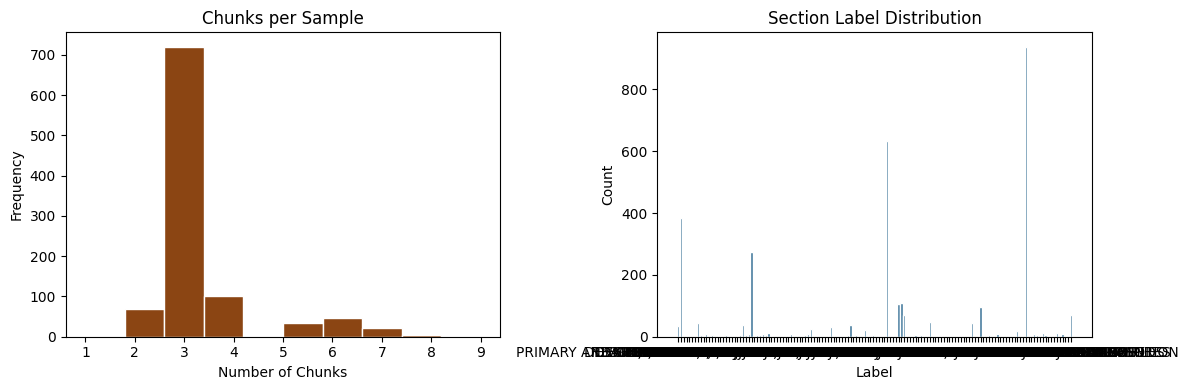

Avg chunks per sample: 3.4
Label distribution: {'PATIENTS': 35, 'BACKGROUND': 385, 'RESULTS AND LIMITATIONS': 1, 'PRIMARY AND SECONDARY OUTCOME MEASURES': 1, 'RESEARCH DESIGN': 1, 'END POINT': 1, 'STUDY SELECTION': 2, 'STUDY DESIGN': 46, 'RATIONALE AND OBJECTIVES': 5, 'KEY LIMITATIONS': 1, 'METHODS AND MATERIALS': 10, 'DESIGN, SETTING, AND PATIENTS': 1, 'PRINCIPAL FINDINGS': 5, 'DESIGN, SETTING, AND PARTICIPANTS': 2, 'OUTCOMES': 1, 'PATIENT AND METHODS': 1, 'MAIN RESEARCH VARIABLES': 1, 'UNLABELLED': 6, ', FSAII': 1, 'CONTEXT AND OBJECTIVES': 1, 'AIMS AND BACKGROUND': 1, 'PROBANDS AND METHODS': 1, 'PURPOSES': 5, 'MAIN OUTCOME MEASURES': 39, 'RESEARCH DESIGN AND METHODS': 4, 'MEASUREMENTS': 10, 'OBJECTIVE': 275, 'METHODS AND STUDY DESIGN': 1, 'OUTCOME MEASURES': 6, 'HYPOTHESIS': 5, 'BACKGROUND AND OBJECTIVES': 8, 'METHODOLOGY': 7, 'STUDY OBJECTIVE': 11, 'RESULTS AND DISCUSSION': 2, 'COLLECTION': 1, 'LOCATION, SUBJECTS, AND INTERVENTIONS': 1, 'PATIENTS AND METHOD': 2, 'PRIMARY OBJECTIVE'

In [4]:
# 3. Chunks per sample + label distribution
chunks_per_sample = [len(s['chunks']) for s in samples]
all_labels = [chunk['label'] for s in samples for chunk in s['chunks']]
label_counts = {l: all_labels.count(l) for l in set(all_labels)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(chunks_per_sample, bins=10, color='#8b4513', edgecolor='white')
ax1.set_title('Chunks per Sample')
ax1.set_xlabel('Number of Chunks')
ax1.set_ylabel('Frequency')

ax2.bar(label_counts.keys(), label_counts.values(), color='#457b9d', edgecolor='white')
ax2.set_title('Section Label Distribution')
ax2.set_xlabel('Label')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Avg chunks per sample: {sum(chunks_per_sample)/len(chunks_per_sample):.1f}")
print(f"Label distribution: {label_counts}")